# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

**Business Problem:**

Airlines receive thousands of customer comments and complaints on social media every day. Reading each tweet manually takes a lot of time, so the goal of this project is to build a machine learning model that can automatically classify customer tweets as positive, negative, or neutral. This can help airlines better understand customer satisfaction and quickly identify common issues.

---

**Dataset Description:**

This project uses a public dataset containing customer tweets directed at major U.S. airlines. Each tweet has already been labeled with a sentiment category, making it suitable for training and evaluating machine learning models for sentiment analysis.

- **Dataset name**: Twitter US Airline Sentiment
- **Source**: Kaggle
- **Number of samples**: 14,640 tweets
- **Text type**: Customer tweets about major U.S. airlines
- **Sentiment labels**: Positive, Neutral, Negative

---

**Importance and Real-World Applications:**

Sentiment analysis helps businesses understand customer opinions without manually reading thousands of comments. Airlines can use these results to identify common complaints, improve customer service, monitor public opinion, and make better business decisions based on customer feedback.

---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Tweets.csv to Tweets (1).csv


In [3]:
df = pd.read_csv('Tweets.csv')
display(df.head())

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
# Load your dataset
# Example: df = pd.read_csv('your_dataset.csv')
# For large datasets, consider using nrows parameter: pd.read_csv('file.csv', nrows=10000)

# YOUR CODE HERE
df = pd.read_csv("Tweets.csv")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head()

Dataset shape: (14640, 15)

Column names: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
# Check for missing values

missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64


In [6]:
# df_sample = df.sample(n=5000, random_state=42)
# print(f"Working with {len(df_sample)} samples")
# df = df_sample

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


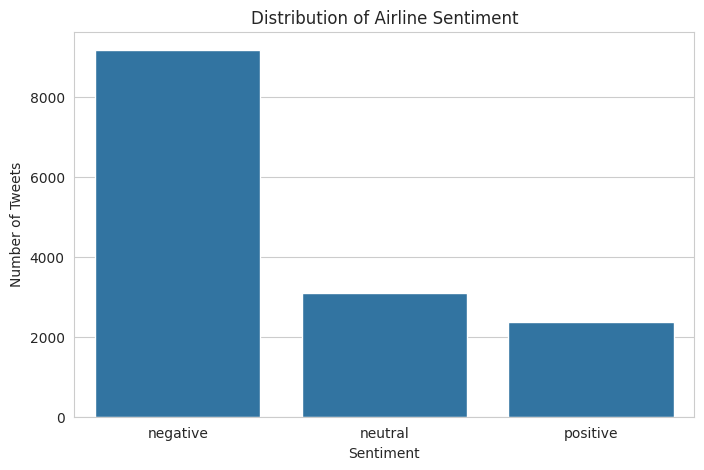

In [7]:
# Analyze sentiment distribution

# Count the number of tweets in each sentiment category
sentiment_counts = df['airline_sentiment'].value_counts()

print(sentiment_counts)

# Create a bar plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='airline_sentiment', order=sentiment_counts.index)

plt.title("Distribution of Airline Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

### 📊 Interpretation: Class Balance

*Write your observations here:*

- Are the classes balanced or imbalanced?

The classes are imbalanced. Most of the tweets are labeled as negative, while there are fewer neutral and positive tweets.

- If imbalanced, how might this affect your model?

The model may become biased toward predicting the negative class because it appears much more frequently in the dataset. This is why it is important to evaluate the model using precision, recall, and a confusion matrix instead of relying only on accuracy.

- What could you do to address imbalance?

Class imbalance can be addressed by collecting more data for the smaller classes or by using techniques such as oversampling, undersampling, or class weighting during model training.

count    14640.000000
mean       103.822063
std         36.277339
min         12.000000
25%         77.000000
50%        114.000000
75%        136.000000
max        186.000000
Name: text_length, dtype: float64


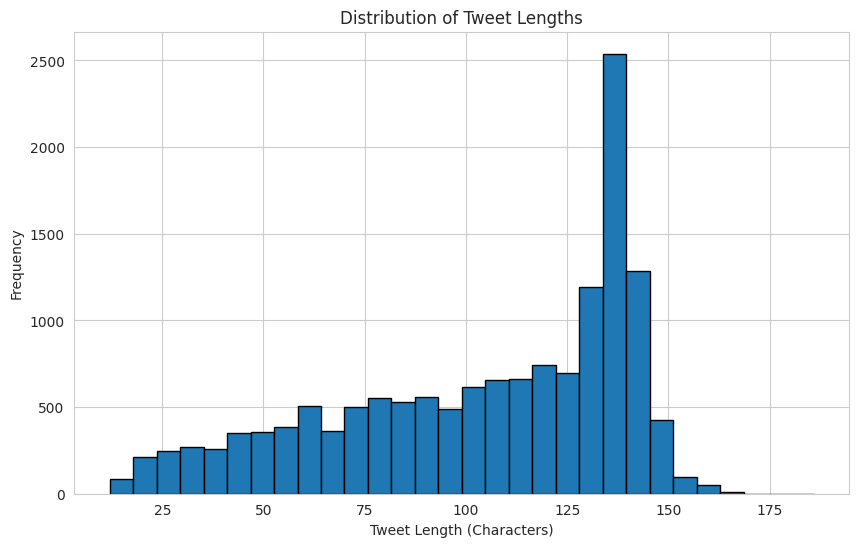

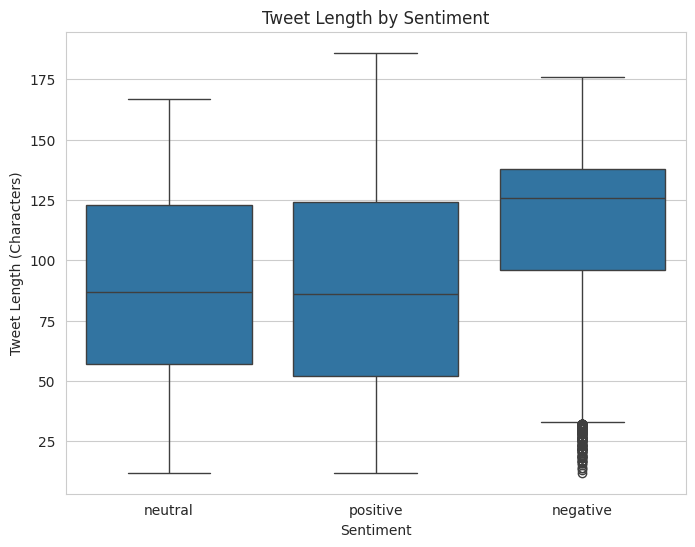

In [8]:
# Analyze text length distribution

# Create a new column for tweet length
df['text_length'] = df['text'].str.len()

# Display summary statistics
print(df['text_length'].describe())

# Plot histogram of text lengths
plt.figure(figsize=(10,6))
plt.hist(df['text_length'], bins=30, edgecolor='black')

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length (Characters)")
plt.ylabel("Frequency")
plt.show()

# Compare text lengths by sentiment
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='airline_sentiment', y='text_length')

plt.title("Tweet Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Length (Characters)")
plt.show()

### 📊 Interpretation: Text Length

*Write your observations here:*
- What's the average text length?

The average tweet length is approximately 104 characters. The shortest tweet is 12 characters, and the longest is 186 characters.

- Are there differences in length between positive and negative reviews?

Based on the boxplot, there are some differences in tweet length between the sentiment categories, but they generally have similar ranges with considerable overlap.

- Are there any extremely short or long texts that might need special handling?

There are some very short and very long tweets, but none appear to be extreme outliers. Since the tweets range from 12 to 186 characters, they can likely be used without any special handling for text length.

In [9]:
# Display sample reviews from each sentiment class

print("Positive Tweets:")
print(df[df['airline_sentiment'] == 'positive']['text'].sample(3, random_state=42))

print("\nNeutral Tweets:")
print(df[df['airline_sentiment'] == 'neutral']['text'].sample(3, random_state=42))

print("\nNegative Tweets:")
print(df[df['airline_sentiment'] == 'negative']['text'].sample(3, random_state=42))

Positive Tweets:
6396    @SouthwestAir thanks for your excellent respon...
8484    @JetBlue thanks. I appreciate your prompt resp...
8417    @JetBlue yes, with about 20 minutes to spare. ...
Name: text, dtype: object

Neutral Tweets:
3569     @united we finally just arrive to Bogota, good...
13566    @AmericanAir got a callback at 1 am, took care...
7452                    @JetBlue is there wifi on he plain
Name: text, dtype: object

Negative Tweets:
1151    @united gate C 24 IAD. U released passengers t...
9111    @USAirways 1729 connecting in charlotte to hou...
3326    @united installed and working are not the same...
Name: text, dtype: object


             Word  Count
0              to   8590
1             the   6034
2               i   5351
3               a   4461
4             for   3964
5         @united   3760
6             and   3693
7              on   3652
8             you   3607
9              my   3272
10         flight   3217
11     @usairways   2938
12   @americanair   2885
13             is   2770
14             in   2446
15  @southwestair   2389
16             of   2109
17       @jetblue   2023
18           your   1731
19           have   1621


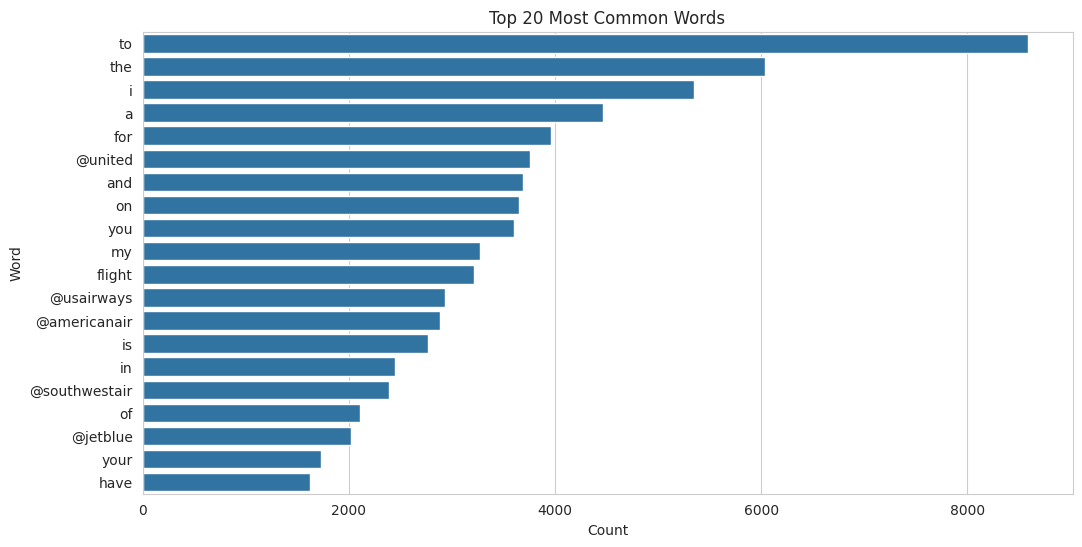

In [10]:
# Analyze common words

# Combine all tweets into one string
all_words = ' '.join(df['text']).lower().split()

# Count the most common words
common_words = Counter(all_words).most_common(20)

# Convert to DataFrame
common_words_df = pd.DataFrame(common_words, columns=['Word', 'Count'])

print(common_words_df)

# Plot the top 20 most common words
plt.figure(figsize=(12,6))
sns.barplot(data=common_words_df, x='Count', y='Word')

plt.title("Top 20 Most Common Words")
plt.xlabel("Count")
plt.ylabel("Word")

plt.show()

### 📝 EDA Summary

*Summarize your key findings from the EDA:*

1. **Dataset characteristics**:

The dataset contains 14,640 airline-related tweets with 15 columns. The sentiment labels are negative, neutral, and positive, with negative tweets making up the largest portion of the dataset. The average tweet length is about 104 characters.

2. **Data quality issues**:

There are missing values in several columns, such as tweet_coord, tweet_location, and user_timezone. However, the two columns needed for this project (text and airline_sentiment) contain no missing values. The tweets also contain mentions (@), stopwords, and other text that will need to be cleaned before modeling.

3. **Key patterns observed**:

The dataset is imbalanced, with many more negative tweets than neutral or positive ones. Common words include airline Twitter handles, common English words, and the word "flight." The sample tweets showed that the sentiment labels appear to accurately reflect the content of the tweets.

4. **Potential challenges**:

The class imbalance may cause the model to favor the negative class. In addition, tweets often contain abbreviations, mentions, punctuation, and informal language, making text preprocessing an important step before training the machine learning models.

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [11]:
# Import preprocessing libraries
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# For stopwords
# Option 1: Use sklearn's built-in stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Option 2: Use NLTK (uncomment if you prefer)
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


In [12]:
# Create a text preprocessing function
def preprocess_text(text):
    """
    Clean and preprocess text data.

    Args:
        text (str): Raw text string

    Returns:
        str: Cleaned text string
    """

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Test your function on a sample text
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"
print(f"Original: {sample_text}")
print(f"Cleaned: {preprocess_text(sample_text)}")

Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned: this is a test check out


In [13]:
# Apply preprocessing to your dataset

# Create a new column with cleaned text
df['cleaned_text'] = df['text'].apply(preprocess_text)

# Display examples to verify the cleaning worked
print(df[['text', 'cleaned_text']].head())

print("✅ Text preprocessing complete!")

                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                        cleaned_text  
0                                          what said  
1  plus youve added commercials to the experience...  
2  i didnt today must mean i need to take another...  
3  its really aggressive to blast obnoxious enter...  
4            and its a really big bad thing about it  
✅ Text preprocessing complete!


In [14]:
# Prepare your features (X) and target (y)

X = df['cleaned_text']
y = df['airline_sentiment']

# Check the shape
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (14640,)
Target shape: (14640,)


In [15]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80% training, 20% testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 11712
Testing samples: 2928


In [16]:
# Create TF-IDF features

tfidf = TfidfVectorizer(
    max_features=5000,      # Limit features to save memory
    min_df=2,               # Ignore terms appearing in fewer than 2 documents
    max_df=0.8,             # Ignore terms appearing in more than 80% of documents
    ngram_range=(1, 2),     # Use unigrams and bigrams
    stop_words='english'    # Remove English stopwords
)

# Fit on training data and transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape (train): (11712, 5000)
TF-IDF matrix shape (test): (2928, 5000)
Number of features: 5000


In [17]:
# Explore the TF-IDF features

feature_names = tfidf.get_feature_names_out()

print("First 20 TF-IDF features:")
for feature in feature_names[:20]:
    print(feature)

First 20 TF-IDF features:
aa
aa agent
aa customer
aa does
aa flight
aadvantage
ability
able
able help
able use
abq
absolute
absolute worst
absolutely
absurd
abt
abysmal
ac
accept
acceptable


### 📝 Preprocessing Summary

*Document your preprocessing choices:*

1. **Preprocessing steps applied**:

The text was converted to lowercase, URLs, mentions, hashtags, punctuation, and numbers were removed, and extra whitespace was cleaned. The cleaned text was stored in a new column before creating the machine learning features.

2. **TF-IDF parameters chosen**:

The TF-IDF vectorizer was configured with max_features=5000, min_df=2, max_df=0.8, ngram_range=(1,2), and stop_words='english'. This allowed the model to use both individual words and two-word phrases while limiting the vocabulary size.

3. **Final feature count**:

The final TF-IDF representation contained 5,000 features. The training set had a shape of (11,712, 5,000), and the testing set had a shape of (2,928, 5,000).


4. **Rationale for choices**:

These preprocessing steps removed unnecessary information and standardized the text while preserving the important words related to sentiment. The TF-IDF parameters helped reduce memory usage, removed very common and very rare terms, and included bigrams so the models could better recognize meaningful phrases such as "absolute worst."

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [18]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [19]:
# Train Logistic Regression model

print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,      # Increase if model doesn't converge
    random_state=42,
    n_jobs=-1           # Use all CPU cores
)

lr_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Logistic Regression...
✅ Training complete in 0:00:01


In [20]:
# Make predictions with Logistic Regression

y_pred_lr = lr_model.predict(X_test_tfidf)

print(f"Predictions shape: {y_pred_lr.shape}")

Predictions shape: (2928,)


## Model 2: Multinomial Naive Bayes

In [21]:
# Train Naive Bayes model

print("Training Multinomial Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Multinomial Naive Bayes...
✅ Training complete in 0:00:00


In [22]:
# Make predictions with Naive Bayes

y_pred_nb = nb_model.predict(X_test_tfidf)

print(f"Predictions shape: {y_pred_nb.shape}")

Predictions shape: (2928,)


## Model 3 (Optional): Additional Model

*Train a third model if you'd like to explore further!*

In [23]:
# Train your third model (optional)
# YOUR CODE HERE

# Example: Random Forest
# print("Training Random Forest...")
# start_time = time.time()

# rf_model = RandomForestClassifier(
#     n_estimators=100,        # Number of trees
#     max_depth=20,            # Limit depth to save memory
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_train_tfidf, y_train)

# training_time = time.time() - start_time
# print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

# y_pred_rf = rf_model.predict(X_test_tfidf)

### 📝 Model Training Summary

*Document your models:*

| Model | Training Time | Parameters | Notes |
|-------|--------------|------------|-------|
| Logistic Regression | 0:00:02 | max_iter=1000, random_state=42, n_jobs=-1 | Trained successfully with no convergence issues. Good baseline model for text classification. |
| Naive Bayes | 0:00:00 | Default MultinomialNB() | Extremely fast to train and well suited for TF-IDF text classification. |
| (Optional) Model 3 | N/A | N/A | Not used (optional). |

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [24]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [25]:
# Calculate metrics for Logistic Regression

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.7650
Precision: 0.7545
Recall:    0.7650
F1-Score:  0.7474


Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.94      0.86      1835
     neutral       0.62      0.42      0.50       620
    positive       0.81      0.55      0.65       473

    accuracy                           0.77      2928
   macro avg       0.74      0.63      0.67      2928
weighted avg       0.75      0.77      0.75      2928



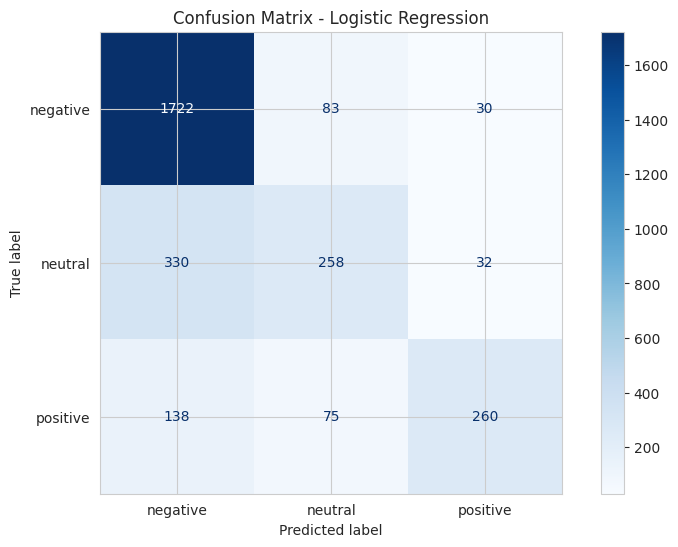

In [26]:
# Plot confusion matrix for Logistic Regression

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_model.classes_
)

disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### 📊 Interpretation: Logistic Regression

*Analyze the results:*

1. **Overall performance**:

The Logistic Regression model performed well overall, achieving an accuracy of 76.50%, a precision of 75.45%, a recall of 76.50%, and an F1-score of 74.74%. It was effective at classifying airline tweet sentiment, especially for negative tweets.

2. **Strengths**:

The model performed very well at identifying negative tweets, with high precision and recall. It also produced good overall accuracy and was able to correctly classify most of the test data.

3. **Weaknesses**:

The model struggled more with neutral tweets, which had the lowest recall and F1-score. Some positive and neutral tweets were incorrectly classified as negative, making those classes more difficult to distinguish.

4. **Confusion matrix insights**:

The confusion matrix shows that most negative tweets were classified correctly (1,722 correct predictions). However, many neutral tweets (330) were misclassified as negative, and some positive tweets (138) were also predicted as negative. This suggests the model is better at recognizing strong negative sentiment than distinguishing between neutral and positive opinions.

## Evaluate Model 2: Naive Bayes

In [27]:
# Calculate metrics for Naive Bayes

print("=" * 50)
print("NAIVE BAYES RESULTS")
print("=" * 50)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average='weighted')
nb_recall = recall_score(y_test, y_pred_nb, average='weighted')
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')

print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1-Score:  {nb_f1:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

NAIVE BAYES RESULTS
Accuracy:  0.7251
Precision: 0.7287
Recall:    0.7251
F1-Score:  0.6786


Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.98      0.83      1835
     neutral       0.67      0.23      0.34       620
    positive       0.84      0.40      0.54       473

    accuracy                           0.73      2928
   macro avg       0.74      0.53      0.57      2928
weighted avg       0.73      0.73      0.68      2928



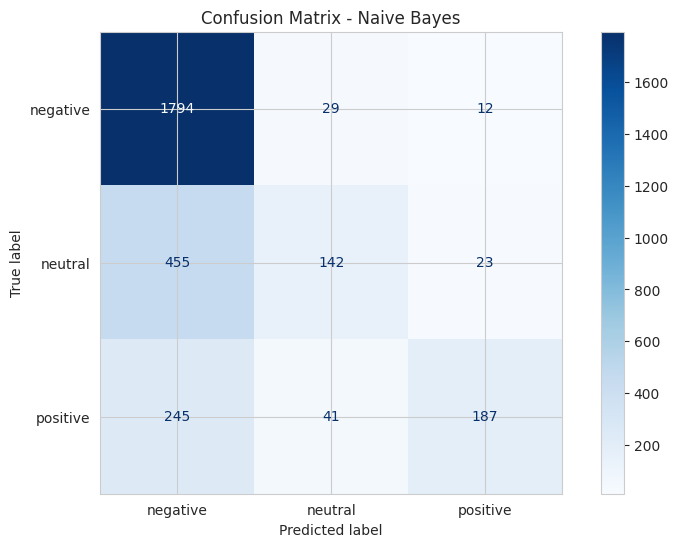

In [28]:
# Plot confusion matrix for Naive Bayes

cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_model.classes_
)

disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - Naive Bayes')
plt.show()

### 📊 Interpretation: Naive Bayes

*Analyze the results:*

1. **Overall performance**:

The Naive Bayes model achieved an accuracy of 72.51%, with a precision of 72.87%, recall of 72.51%, and F1-score of 67.86%. While it performed reasonably well, its overall performance was lower than the Logistic Regression model.

2. **Strengths**:

The model performed very well at identifying negative tweets, correctly classifying 1,794 negative reviews. It was also extremely fast to train, taking less than one second.


3. **Weaknesses**:

The model struggled to correctly classify neutral and positive tweets. Many of these tweets were incorrectly predicted as negative, resulting in lower recall and F1-scores for those classes.

4. **Confusion matrix insights**:

The confusion matrix shows that 455 neutral tweets and 245 positive tweets were incorrectly classified as negative. This indicates that the model tended to favor the majority negative class, making it less effective at distinguishing neutral and positive sentiment compared to Logistic Regression.

## Evaluate Model 3 (Optional)

In [29]:
# Calculate metrics for your third model (if applicable)
# YOUR CODE HERE

In [30]:
# Plot confusion matrix for your third model (if applicable)
# YOUR CODE HERE

## Model Comparison

In [31]:
# Create a comparison table of all models

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [lr_accuracy, nb_accuracy],
    'Precision': [lr_precision, nb_precision],
    'Recall': [lr_recall, nb_recall],
    'F1-Score': [lr_f1, nb_f1]
})

display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.765027,0.754545,0.765027,0.747373
1,Naive Bayes,0.725068,0.728714,0.725068,0.678644


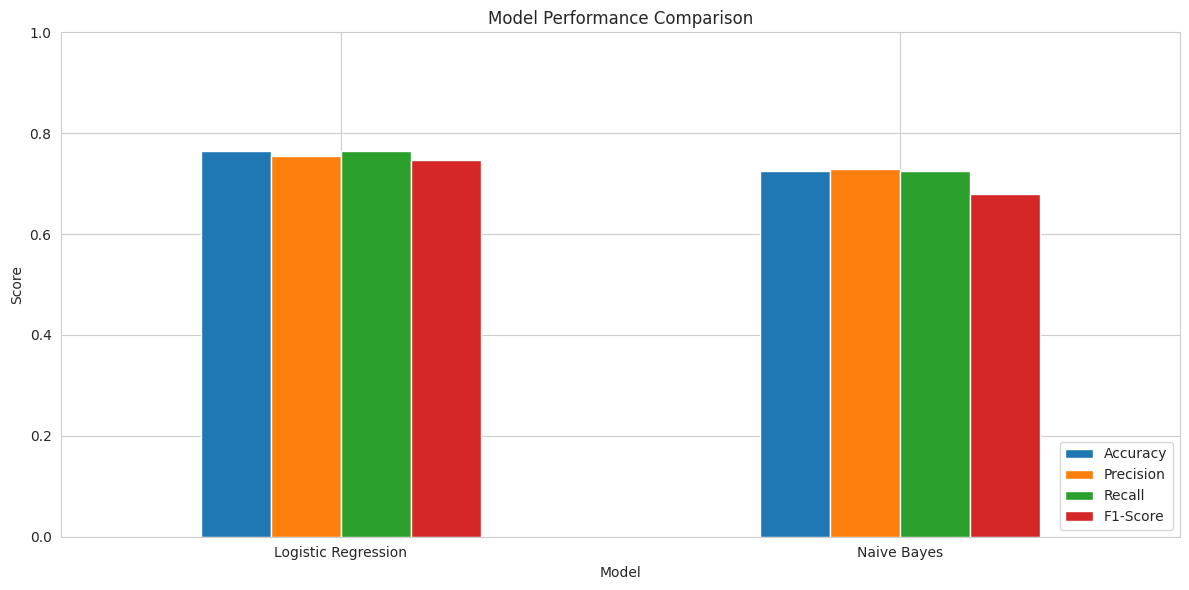

In [32]:
# Visualize model comparison

results.set_index('Model').plot(kind='bar', figsize=(12, 6))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)          # Makes the chart easier to read
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 📊 Model Comparison Analysis

*Compare and contrast your models:*

1. **Which model performed best?**:

Logistic Regression performed the best overall. It achieved higher accuracy (76.50%), precision (75.45%), recall (76.50%), and F1-score (74.74%) than the Naive Bayes model.

2. **What metrics did you prioritize and why?**:

I prioritized the F1-score and accuracy because the dataset was imbalanced, with many more negative tweets than neutral or positive ones. The F1-score provides a better measure of overall performance by balancing precision and recall, while accuracy shows the overall percentage of correct predictions.

3. **Trade-offs between models**:

Logistic Regression provided more balanced performance across all three sentiment classes but required slightly more training time (about 2 seconds). Naive Bayes trained almost instantly but tended to classify many neutral and positive tweets as negative, resulting in lower overall performance.

4. **Which model would you recommend for deployment?**:

I would recommend Logistic Regression because it achieved the best overall performance and produced more balanced predictions across all sentiment classes. This would make it a better choice for helping an airline accurately understand customer feedback and improve customer service.

## Error Analysis (Optional but Recommended)

In [33]:
# Analyze misclassified examples

misclassified_indices = np.where(y_pred_lr != y_test)[0]

print(f"Number of misclassified examples: {len(misclassified_indices)}")

# Display some misclassified examples
for idx in misclassified_indices[:5]:
    print(f"\nText: {X_test.iloc[idx]}")
    print(f"True label: {y_test.iloc[idx]}")
    print(f"Predicted label: {y_pred_lr[idx]}")
    print("-" * 80)

Number of misclassified examples: 688

Text: past
True label: neutral
Predicted label: negative
--------------------------------------------------------------------------------

Text: would you say a delay is more likely thanks so much
True label: positive
Predicted label: negative
--------------------------------------------------------------------------------

Text: this link in your tweet goes to someones internal email gt probably one of your rd party it contracts
True label: neutral
Predicted label: negative
--------------------------------------------------------------------------------

Text: when will the flight resume i dons see it in the open schedule
True label: negative
Predicted label: neutral
--------------------------------------------------------------------------------

Text: of course but they were just as helpless as everyone else
True label: negative
Predicted label: positive
--------------------------------------------------------------------------------


### 📊 Error Analysis Insights

*What patterns do you notice in the errors?*

1. **Common types of errors**:

The most common errors were neutral and positive tweets being classified as negative. The model also made mistakes on very short tweets or tweets with mixed sentiment.

2. **Why might these errors occur?**:

These errors likely occurred because the dataset contained more negative tweets than the other classes, making the model more likely to predict the majority class. In addition, some tweets lacked enough context or contained both positive and negative wording, making the sentiment difficult to determine.

3. **How could you improve the model?**:

The model could be improved by balancing the dataset, tuning hyperparameters, using more advanced text preprocessing, or testing other machine learning models such as Support Vector Machines (SVM). Adding more training data or using word embeddings could also improve classification accuracy.

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

*Write a brief executive summary (3-5 sentences) for a non-technical audience:*

This project analyzed thousands of airline customer tweets to determine whether customer opinions were positive, neutral, or negative. Two machine learning models were tested, and Logistic Regression provided the best overall performance, correctly classifying customer sentiment about 77% of the time. The results show that sentiment analysis can help airlines quickly identify customer concerns, monitor public opinion, and improve customer service by responding to negative feedback more efficiently. Overall, this project demonstrates how machine learning can turn large amounts of customer feedback into valuable business insights.


## 🎯 Key Findings

*List your main discoveries:*

1. **Dataset insights**:
   - The dataset contained 14,640 airline tweets labeled as positive, neutral, or negative sentiment.
   - The data was imbalanced, with negative tweets being the largest class (9,178), followed by neutral (3,099) and positive (2,363).
   - Most tweets were relatively short, with an average length of about 104 characters.

2. **Model performance**:
   - Both Logistic Regression and Naive Bayes successfully classified tweet sentiment.
   - Logistic Regression achieved the best overall results with 76.50% accuracy and an F1-score of 74.74%.
   - Naive Bayes performed reasonably well but had lower overall accuracy (72.51%) and struggled more with neutral and positive tweets.

3. **Best model and why**:
   - Logistic Regression was the best-performing model because it achieved the highest accuracy, precision, recall, and F1-score.
   - It also provided more balanced predictions across all three sentiment classes than Naive Bayes.

4. **Surprising discoveries**:
   - Both models were much better at identifying negative tweets than neutral or positive ones.
   - Neutral tweets were the most difficult to classify because they often contained ambiguous language or lacked enough context.
   - Even a simple Logistic Regression model performed well on text classification, showing that basic machine learning techniques can be effective for sentiment analysis.

## 💼 Business Recommendations

*How can these results be used in practice?*

1. **Immediate applications**:
   - Airlines can use this model to automatically analyze customer feedback from social media and identify negative comments that may require a quick response. It can also help track customer satisfaction trends and identify common service issues.
2. **Who should use this model?**:
   - Customer service teams, social media managers, marketing departments, and airline management could all benefit from using this model to monitor customer sentiment and improve the customer experience.

3. **How to interpret predictions**:
   - The model's predictions should be used as a decision-support tool rather than a final judgment. Negative predictions can be prioritized for review, while neutral and positive predictions can help measure overall customer satisfaction and identify areas of success.
4. **Warning signs to watch for**:
   - The model is less accurate when classifying neutral and positive tweets and may occasionally misclassify them as negative. Because of this, important business decisions should not rely solely on the model's predictions, and uncertain cases should be reviewed by a person.

## ⚠️ Limitations

*Be honest about the limitations of your analysis:*

1. **Data limitations**:
   - The dataset was imbalanced, with many more negative tweets than neutral or positive tweets. In addition, the tweets were relatively short and sometimes lacked enough context to clearly determine the intended sentiment.

2. **Model limitations**:
   - Both models had difficulty correctly classifying neutral and positive tweets. Logistic Regression achieved about 76.5% accuracy, which means some predictions were still incorrect, especially for ambiguous or mixed-sentiment tweets.

3. **Generalization concerns**:
   - These models were trained using airline tweets from a specific dataset. Their performance may decrease when applied to customer feedback from other industries or to newer social media posts that use different language, slang, or writing styles.

4. **Resource constraints**:
   - To keep training efficient, the TF-IDF vectorizer was limited to 5,000 features, and only two machine learning models were evaluated. More computing resources would allow testing additional models, larger feature sets, and more extensive hyperparameter tuning, which could potentially improve performance.

## 🚀 Future Improvements

*What would you do with more time/resources?*

1. **Data collection**:
   - Collect a larger and more balanced dataset with additional neutral and positive tweets. It would also be helpful to include more recent tweets and customer feedback from multiple airlines to improve the model's ability to generalize.

2. **Feature engineering**:
   - Experiment with additional preprocessing techniques, such as lemmatization, stemming, sentiment lexicons, or more advanced n-gram features. Other text representations, such as word embeddings, could also capture more meaning than TF-IDF alone.

3. **Advanced models**:
   - Test more advanced machine learning models such as Support Vector Machines (SVM), Random Forest, XGBoost, or transformer-based models like BERT. Hyperparameter tuning could also improve model performance.

4. **Deployment considerations**:
   - Deploy the model as part of a real-time dashboard that monitors customer sentiment from social media. The system should be retrained periodically with new data and allow human review of uncertain predictions to maintain accuracy and adapt to changing language patterns.

## 🎓 Lessons Learned

*Reflect on your experience:*

1. **Technical skills gained**:
   - I learned how to preprocess text data, convert text into numerical features using TF-IDF, train multiple machine learning models, and evaluate their performance using accuracy, precision, recall, F1-score, and confusion matrices. I also gained experience comparing models and interpreting their results.

2. **Challenges overcome**:
   - One of the biggest challenges was working with text data and understanding the preprocessing steps needed before training a model. I also learned how to interpret evaluation metrics and understand why different models performed differently on the same dataset.

3. **What would you do differently?**:
   - If I repeated this project, I would experiment with additional preprocessing techniques, tune the model hyperparameters, and test more advanced machine learning models such as Support Vector Machines or transformer-based models to see if they improve performance.

4. **Most valuable insight**:
   - The most valuable insight was learning that choosing the right model is about more than just accuracy. Comparing multiple evaluation metrics and understanding where a model makes mistakes are essential for selecting the best solution for a real-world business problem.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*